In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio      # βιβιοθήκη για να "παίζουμε" ήχους (μεταξύ άλλων)
import pandas as pd
from scipy.io import wavfile           # βιβλιοθήκη για να "διαβάζουμε" .wav files (μεταξύ άλλων)

## Άσκηση - Σύνθεση μουσικής

Μια μουσική σύνθεση δεν είναι τίποτε άλλο από ένας συνδυασμός από νότες, ή σήματα, σε διάφορες συχνότητες. Μια οκτάβα καλύπτει το εύρος συχνοτήτων από $f_0$ ως $2f_0$. Στη Δυτική μουσική κλίμακα, υπάρχουν $12$ νότες ανά οκτάβα, λογαριθμικά τοποθετημένες σε ίσες αποστάσεις. Οι συχνότητες από τις προαναφερθείσες νότες υπολογίζονται ως

$$f = 2^{k/12}f_0$$

Οι $12$ νότες έχουν ως ακολουθως: (τα $\sharp$ και $\flat$ σημαίνουν δίεση και ύφεση)

Α $\:\:\:$ (Α $^\sharp$ ή Β $^\flat$) $\:\:\:$ B $\:\:\:$ C $\:\:\:$ (C $^\sharp$ ή D $^\flat$) $\:\:\:$ D $\:\:\:$ (D $^\sharp$ ή E $^\flat$) $\:\:\:$ E $\:\:\:$ F $\:\:\:$ (F $^\sharp$ ή G $^\flat$) $\:\:\:$ G $\:\:\:$ (G $^\sharp$ ή A $^\flat$)  

Στην Ινδική κλασική μουσική, η $\textbf{raga}$ είναι μια μουσική σύνθεση βασισμένη σε μια ανοδική και καθοδική κλίμακα. Οι νότες και η διάταξή τους συνθέτους ένα μουσικό αλφάβητο και μια γραμματική από την οποία ο τραγουδιστής κατασκευάζει μουσικά "κείμενα" βασισμένος μόνο στις επιτρεπόμενες νότες. Η εκτέλεση ενός τέτοιου κομματιού μπορεί να διαρκέσει από μερικά λεπτά ως και μια ώρα - ή και παραπάνω!

Η $\textbf{raga malkauns}$ είναι μια πεντατονική $\textbf{raga}$ (δηλ. με πέντε νότες) και τις ακόλουθες κλίμακες:

#### Άνοδος:
D $\:\:\:$ F $\:\:\:$ G $\:\:\:$ B $^\flat$ $\:\:\:$ C $\:\:\:$ D

#### Κάθοδος:
C $\:\:\:$ B $^\flat$ $\:\:\:$ G $\:\:\:$ F $\:\:\:$ D

Η τελική νότα (η D δηλαδή) σε κάθε κλίμακα διαρκεί δυο φορές περισσότερο από τις υπόλοιπες. Για να συνθέσει κανείς την κλίμακα σε ```Python```, ξεκινάμε από μια συχνότητα $f_0$ που αντιστοιχεί στην πρώτη νότα D και ανεβαίνουμε υψηλότερα σε συχνότητα για να πάρουμε τις νότες στην ανοδική κλίμακα. Όταν φτάσουμε στη νότα D, που είναι μια οκτάβα ψηλότερα, πάμε προς χαμηλότερες συχνότητες, για να πάρουμε νότες σε φθίνουσα κλίμακα. 

In [2]:
fs = 16000 # Insert code here  # συχνότητα δειγματοληψίας (Hz): επιλέξτε μια μεταξύ 8000, 16000, και 22050

# διάρκειες (seconds)
dur_note = 0.4
dur_silence_long = 0.1
dur_silence_short = 0.05
dur_last = 1.0

# συχνότητες με βάση το D
f0 = 340.0  # επιλέγω D ως ~340 Hz
D = f0
F = 2**(3/12)*f0    # νότα F
G = 2**(5/12)*f0     # νότα G
Bb = 2**(8/12)*f0    # νότα Β^b ή Α^#
C = 2**(10/12)*f0    # νότα C
D_up = 2 * D           # μια οκτάβα πάνω από τη D

Συνθέστε ημιτονοειδή σήματα σε αυτές τις συχνότητες με τη συνάρτηση δειγματοληψίας που επιλέξατε, συνενώστε τα, υποθέτοντας μια παύση ανάμεσά τους, και ακούστε το τελικό αποτέλεσμα. Σας δίνεται μια βοηθητική συνάρτηση παρακάτω για να κατασκευάσετε τα ημίτονά σας.

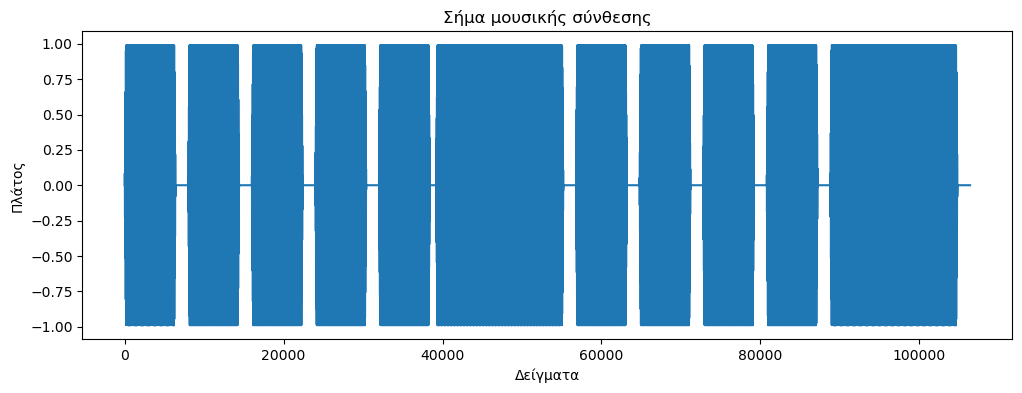

In [3]:
# Συνάρτηση για κατασκευή ημιτόνου συχνότητας freq, διάρκειας dur, συχνότητας δειγματοληψίας fs
def sine(freq, dur, fs=fs):
    t = np.arange(0, int(dur*fs)) / fs # άξονας χρόνου
    x = np.sin(2*np.pi*freq*t)             # χρησιμοποιήστε τον άξονα t, τη συχνότητα freq και προφανώς τη συνάρτηση sin()
    
    # Το παραπάνω αρκεί αλλά προσθέτουμε ένα Audio DSP hack: 
    # βάζουμε ένα μικρό fade-in/fade out για να αποφύγουμε τα περίφημα clicks κατά τη συνένωση
    n = len(x)
    m = max(1, int(0.01 * fs))  # 10 ms fade
    env = np.ones(n)
    r = np.linspace(0, 1, m, endpoint=True)
    env[:m] = r
    env[-m:] = r[::-1]
    return (x * env).astype(np.float32)

# Συνάρτηση για την κατασκευή του σήματος σιωπής διάρκειας dur
def silence(dur, fs=fs):
    return np.zeros(int(dur*fs), dtype=np.float32)

# Παύσεις
s1 = silence(dur_silence_long)
s2 = silence(dur_silence_short)

# Νότες - καλέστε τη sine με κατάλληλα ορίσματα
d = sine(D, dur_note)
f = sine(F, dur_note)
g = sine(G, dur_note)
bb = sine(Bb, dur_note)
c = sine(C, dur_note)
d_last_up = sine(D_up, dur_last)
d_last = sine(D, dur_last)

# Άνοδος και κάθοδος (με σιωπές ανάμεσα)
ascending = np.concatenate([d, s1, f, s1, g, s1, bb, s1, c, s2, d_last_up])
descending = np.concatenate([c, s1, bb, s1, g, s1, f, s1, d_last])

# Τελικό σήμα ως συνένωση των προηγούμενων με μια πάυση ανάμεσα
y = np.concatenate([ascending, s1, descending, s1])

# Κανονικοποίηση
y = y/(1.01*(np.max(np.abs(y))))

# Απεικόνιση του σήματος
plt.figure(figsize=(12, 4))
plt.plot(y)
plt.title("Σήμα μουσικής σύνθεσης")
plt.xlabel("Δείγματα")
plt.ylabel("Πλάτος")
plt.show()

In [4]:
Audio(y, rate=fs)  # Παίζουμε τον ήχο

In [5]:
# Ας δούμε και ποιές συχνότητες χρησιμοποιήσαμε...
freqs = {
    "D4 (~base)": D,
    "F4": F,
    "G4": G,
    "Bb4": Bb,
    "C5": C,
    "D5 (octave)": D_up
}

# ... σε ένα dataframe, για να δείτε τις νότες σας πιο "όμορφα"
df = pd.DataFrame([freqs])
display(df)

,D4 (~base),F4,G4,Bb4,C5,D5 (octave)
0,340.0,404.330419,453.84555,539.716358,605.811128,680.0


----
----